In [1]:
# EDA : Exploratory Data Analysis = 탐색적 데이터 분석과정
# 문제정의 -> 데이터 수집 기획 -> 수집 -> 저장 -> 분석 -> 예측
# EDA
# 1) 데이터 출처, 주제 -> 데이터 신뢰도, 도메인 특성 이해
# 2) 데이터 크기 -> 데이터 신뢰도 (편차, 분산, 표준편차, 상관관계, 사분위 데이터 등)
# 3) 데이터 구성요소 (column => feature) 속성(중요도 -> 결과를 발생시키는데 미친 영향, 각각의 속성들이 그 최종결과에 어떤 상관관계 기여하는가 등) 확인
# 속성 = property = 테슬라 자동차 => 속성 (브레이크, 핸들, 사이드미러, 타이어)
# feature 데이터를 얼마나 더 깊게 이해하고, 각 feature 간 상관관계를 잘 분석할 수 있을까?

* 데이터 구성요소 속성확인

1) 위치추정 & 변이추청
- 위치추정 : 현재 전체 데이터의 대표값을 구해서 해당 feature의 정보를 도출
(* 일반적으로 데이터의 평균값을 도출해서 각 요소 속성을 확인 -> 해당 요소의 값이 일반적, 특이값)
- 변이추정 : 현재 전체 데이터의 분포 (산점도 그래프 | 박스플롯 등 데이터 밀집도) 를 기준으로 데이터가 어디에 포함되어있는지를 확인해서 feature의 정보를 도출
> 위치추정 만으로 데이터 구성요소 속성 정의 -> 평균 모순 함정 (1, 2, 3, 100)
- 편차 (deviation) : 개별적인 데이터 - 평균
- 분산 (variance) : 편차 값의 평균을 구하기 위해서 편차값에 제곱을 한 값
> 모분산 (전체데이터가 결정된 상태에서 분산을 구하고자 할 때
> 표분산 (아직 전체데이터의 갯수가 결정되지 않은 상태, 표본샘플만을 가지고 분산을 구하고자 하는 경우
> 이미 전체 데이터 확정된 상황 (모분산)
> 출구조사 (전체 투표참여자 몇 명 x)
- 표준편차 (standard deviation) : 편차의 제곱으로 원래의 값이 상대적으로 커진 분산의 값을 원래값의 정도로 다시 축소시킨 값
- 평균 (mean) : 모든 값을 더해서 모든 데이터의 갯수만큼 나눈값
- 가중평균 (weighted mean) : 각각의 값이 가지고 있는 고유한 가중치를 반영해서 평균값을 구하는 것
- 중간값 (median) : 평균의 모순 함정을 벗어나기 위해서 전체 데이터의 중간의 값을 구하는 것 (홀수, 짝수)
- 가중중간값 (weighted median) : 중간값의 후보값들이 가지고 있는 가중치를 반영해서 최종 중간값을 구하는 것
- 절사평균 (trimmed mean) : 전체 데이터에서 이상치값으로 판단할 수 있는 상위.하위 값을 제거한 후 내부 값만 가지고 평균을 구하는 것

In [2]:
import pandas as pd

df = pd.DataFrame({
    "A": [1, 2, 3, 4, 5, 6],
    "B": [1, 2, 3, 4, 5, 100]
})
df

,A,B
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
5,6,100


In [3]:
df.describe()

,A,B
count,6.000000,6.000000
mean,3.500000,19.166667
std,1.870829,39.625329
min,1.000000,1.000000
25%,2.250000,2.250000
50%,3.500000,3.500000
75%,4.750000,4.750000
max,6.000000,100.000000


* 데이터 구성요소 속성확인

1) 방법론 : 위치추정 & 변이추청 -> 데이터프레임.describe()
2) 방법론 : 수치형 & 범주형 -> 데이터프레임.describe() -> 5 number summary (박스플롯 차트를 통해서 수집가능한 데이터를 요약) 데이터 활용
   
> 수치형 데이터 : (거의) 숫자
1) 연속형(continuous) 데이터 : 값이 끊기지 않고 쭉~ 계속해서 이어지는 수치형 데이터 : 키, 몸무게, 시간, 온도 등
(170, 170.1, 170. ~~~ 200)
- 꺽은선 그래프차트, 히스토그램차트 (시간대, 요일대 구매금액, 체류시간)

2) 이산형(discrete) 데이터 : 딱딱 값이 떨어지는 수치형 데이터 : 매장 내방객수, 주문건수, 클릭수
- 가로 | 세로 막대그래프 차트, 누적 리본차트 (유입방문자 수, 클릭횟수, 방문객수)
 
> 범주형 데이터 : (대체적으로) 문자열
1) 명목형(nomial) 데이터 : 순서가 존재하지 않는 단순 분류 데이터 : 성별 / 국가 / 브랜드 -> 남.여 / 한국.미국.일본 / 나이키.아디다스
- 파이차트, 도넛차트
 
2) 순서형(ordinal) 데이터 : 순서는 존재하지만, 각 데이터간 간격은 의미가 없는 데이터 :
- 설문조사 : 매우만족 > 만족 > 보통 > 불만 > 매우불만
- 고객등급 : VIP > GOLD > SILVER > BRONZE
- 학점 : A > B > C > D > F
- 세로 막대그래프차트, 파이차트, 계기차트, 산점도그래프차트


In [8]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "A": [1, 2, 3, 4, 5, 6],
    "B": [1, 2, 3, 4, 5, 100],
})

df

,A,B
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
5,6,100


In [9]:
df.describe()

,A,B
count,6.000000,6.000000
mean,3.500000,19.166667
std,1.870829,39.625329
min,1.000000,1.000000
25%,2.250000,2.250000
50%,3.500000,3.500000
75%,4.750000,4.750000
max,6.000000,100.000000


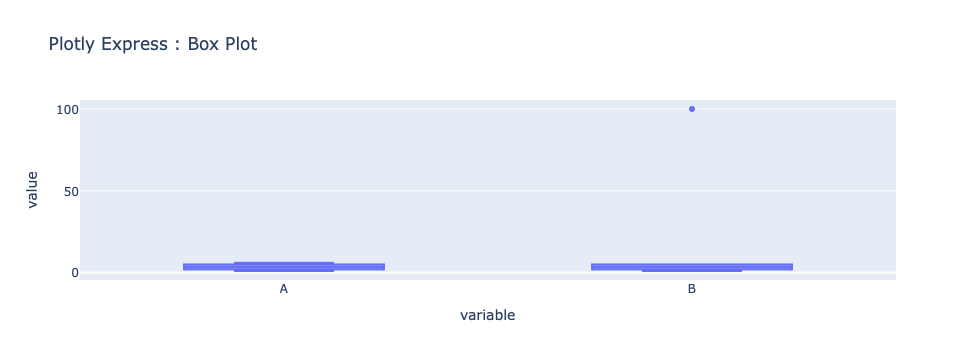

In [10]:
import plotly.express as px

fig = px.box(
    df, y = ["A", "B"], title="Plotly Express : Box Plot"
)

fig.show()

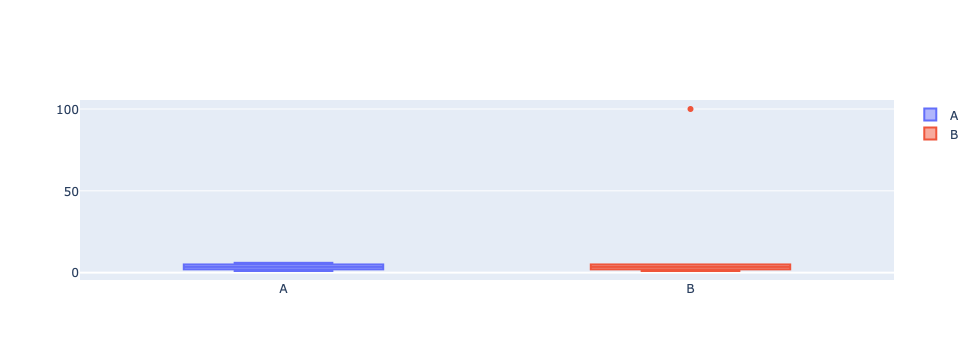

In [11]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Box(
        y=df["A"], name="A"
    )
)

fig.add_trace(
    go.Box(
        y=df["B"], name="B"
    )
)

fig.show()

In [12]:
import numpy as np
import pandas as pd

df = pd.DataFrame(np.random.rand(10000, 1), columns=["A"])

df.head()

,A
0,0.721580
1,0.171846
2,0.157534
3,0.781050
4,0.087505


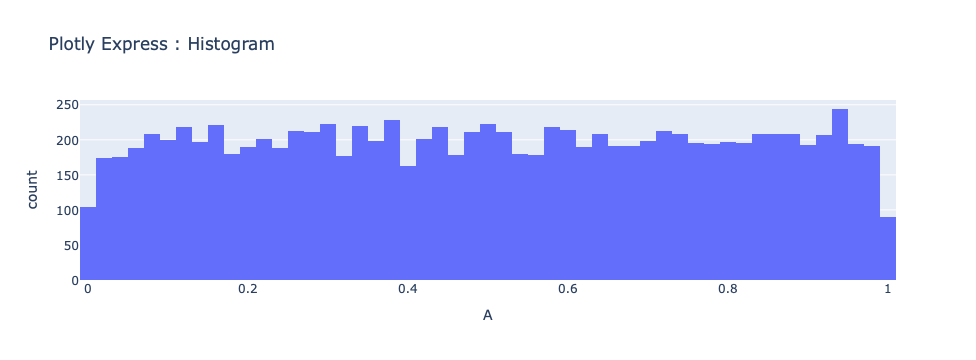

In [13]:
import plotly.express as px

fig = px.histogram(
    df,
    x="A",
    nbins=50,
    title="Plotly Express : Histogram"
)

fig.show()

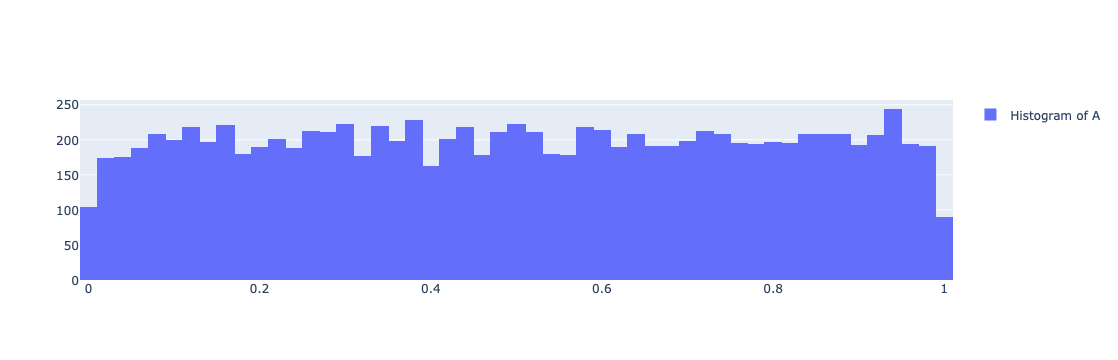

In [15]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Histogram(
        x=df["A"],
        nbinsx=50,
        name= "Histogram of A",
        showlegend=True
    )
)

fig.show()

In [17]:
import pandas as pd

data = {
    "year": ["2017", "2017", "2019", "2020", "2021", "2021"],
    "grade": ["C", "C", "B", "A", "B", "E"]
}

df = pd.DataFrame(data)

,year,grade
0,2017,C
1,2017,C
2,2019,B
3,2020,A
4,2021,B
5,2021,E


In [18]:
df1 = df.groupby("year").count()
df2 = df.groupby("grade").count()

In [19]:
df1

,grade
year,
2017,2
2019,1
2020,1
2021,2


In [20]:
df2

,year
grade,
A,1
B,2
C,2
E,1


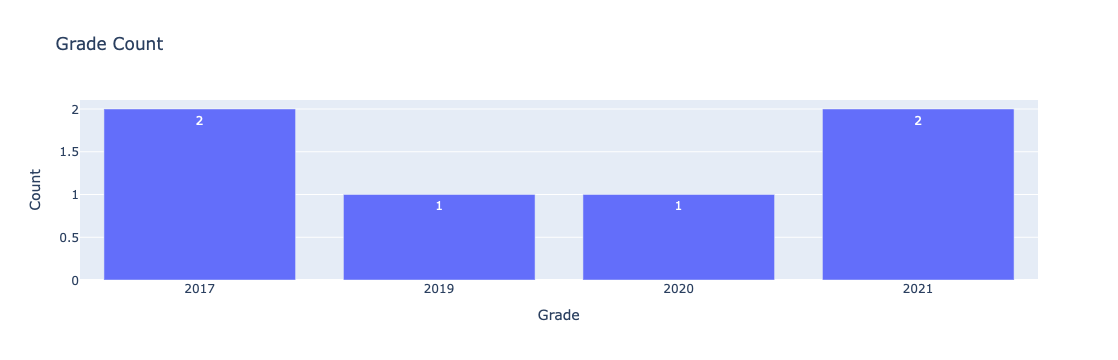

In [23]:
import plotly.express as px

fig1 = px.bar(
    x = df1.index,
    y = df1["grade"],
    title = "Grade Count",
    labels = {"x": "Grade", "y": "Count"},
    text = df1["grade"]
)

fig1.show()

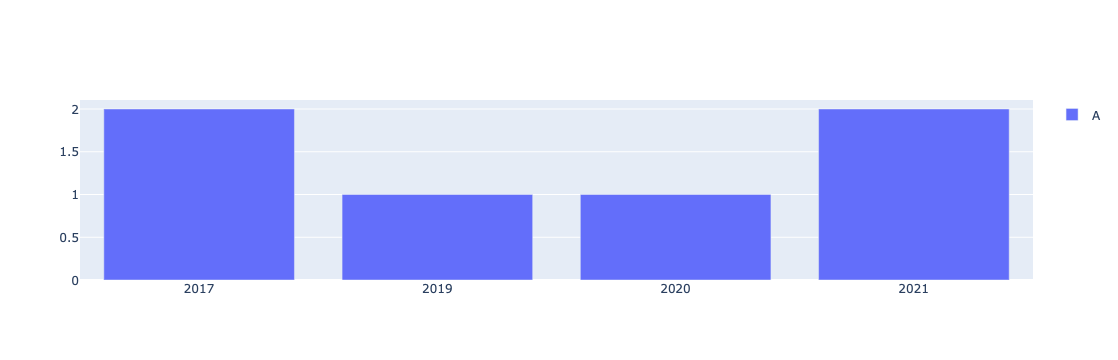

In [26]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x = df1.index,
        y = df1["grade"],
        name = "A",
        showlegend=True
    )
)

fig.show()

In [27]:
# 원그래프 차트 = 파이 차트 = pie chart

import pandas as pd

data = {
    "year": ["2017", "2017", "2019", "2020", "2021", "2021"],
    "grade": ["C", "C", "B", "A", "B", "E"]
}

df = pd.DataFrame(data)

df1 = df.groupby("year").count()
df2 = df.groupby("grade").count()

In [28]:
df1

,grade
year,
2017,2
2019,1
2020,1
2021,2


In [29]:
df2

,year
grade,
A,1
B,2
C,2
E,1


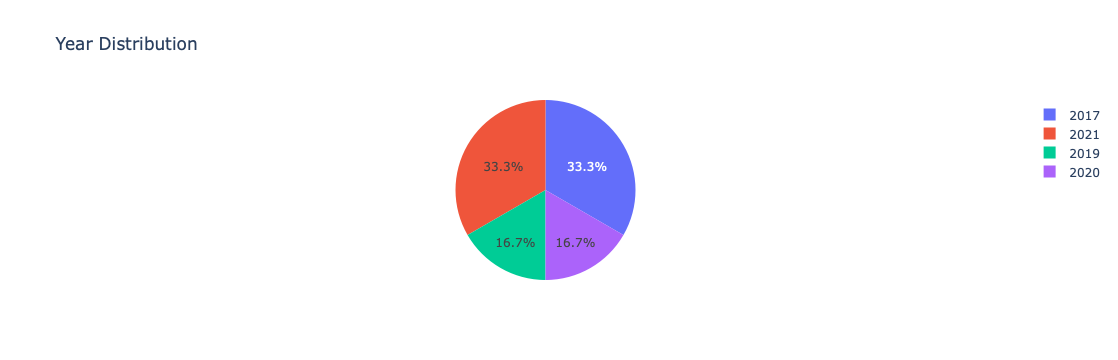

In [32]:
import plotly.express as px

fig = px.pie(
    values=df1["grade"],
    names=df1.index,
    title="Year Distribution"
)

fig.show()

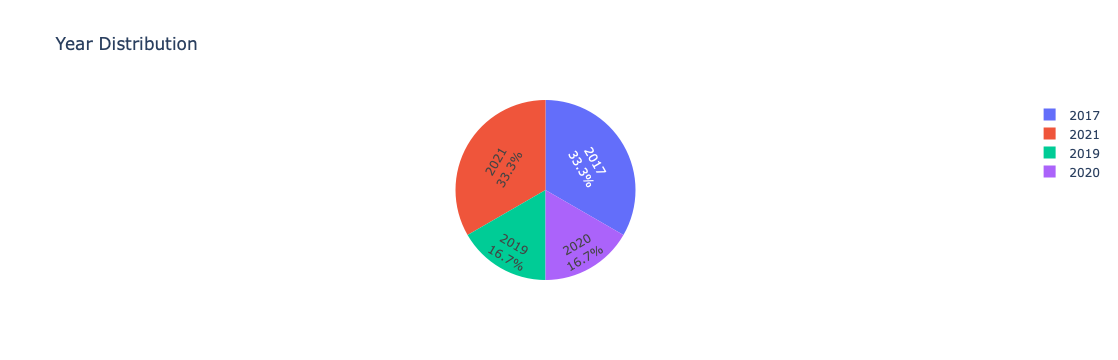

In [40]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Pie(
        labels=df1.index,
        values=df1["grade"],
        textinfo="label+percent",
        insidetextorientation="tangential" # horizontal, radial, tangential
    )
)

fig.update_layout(title_text="Year Distribution")

fig.show()

In [46]:
import pandas as pd

date_index = pd.date_range(start="2026-01-01", end="2026-12-31", freq="2D") # 시작날짜, 종료날짜 -> 데이터를 생성)
df = pd.DataFrame(data = range(len(date_index)), columns=["count"], index=date_index)

df

,count
2026-01-01,0
2026-01-03,1
2026-01-05,2
2026-01-07,3
2026-01-09,4
...,...
2026-12-23,178
2026-12-25,179
2026-12-27,180
2026-12-29,181


In [42]:
pd.date_range(start="2026-01-01", end="2026-12-31", periods=3) # 시작부터 종료까지 날짜를 몇 개의 그룹으로 등분

DatetimeIndex(['2026-01-01', '2026-07-02', '2026-12-31'], dtype='datetime64[ns]', freq=None)

In [43]:
pd.date_range(start="2026-01-01", end="2026-12-31", freq="3ME")

DatetimeIndex(['2026-01-31', '2026-04-30', '2026-07-31', '2026-10-31'], dtype='datetime64[ns]', freq='3ME')

In [ ]:
# freq : 사용가능한 매개변수 값
# ME = Month end frequency
# QE = Quarter end frequency
# YE = Year and frequency
# D = Day frequency
# h = Hourly frequency
# min = Minutely frequency
# s = Secondly frequency

In [53]:
import pandas as pd

date_index = pd.date_range(start="2026-01-01", end="2026-12-31", freq="ME") # 시작날짜, 종료날짜 -> 데이터를 생성)
df = pd.DataFrame(data = range(len(date_index)), columns=["count"], index=date_index)

df

,count
2026-01-31,0
2026-02-28,1
2026-03-31,2
2026-04-30,3
2026-05-31,4
2026-06-30,5
2026-07-31,6
2026-08-31,7
2026-09-30,8
2026-10-31,9


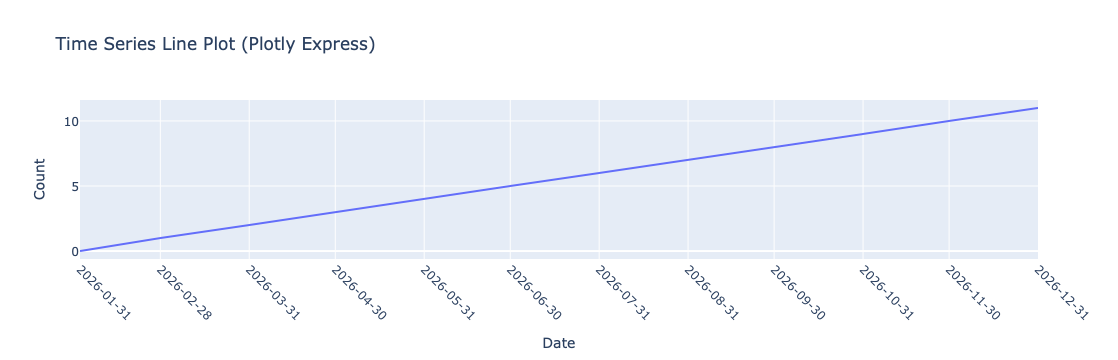

In [79]:
import plotly.express as px

fig_line = px.line(
    df,
    x=df.index,
    y=df["count"],
    title= "Time Series Line Plot (Plotly Express)"
)

# fig_line.update_xaxes(
#     title="Date",
#     tickmode="linear",
#     tickangle=45
# )
fig_line.update_xaxes(
    title="Date",
    tickangle=45,
    tickvals=df.index,
    ticktext=[date.strftime("%Y-%m-%d") for date in df.index]
)
fig_line.update_yaxes(title="Count")

fig_line.show()

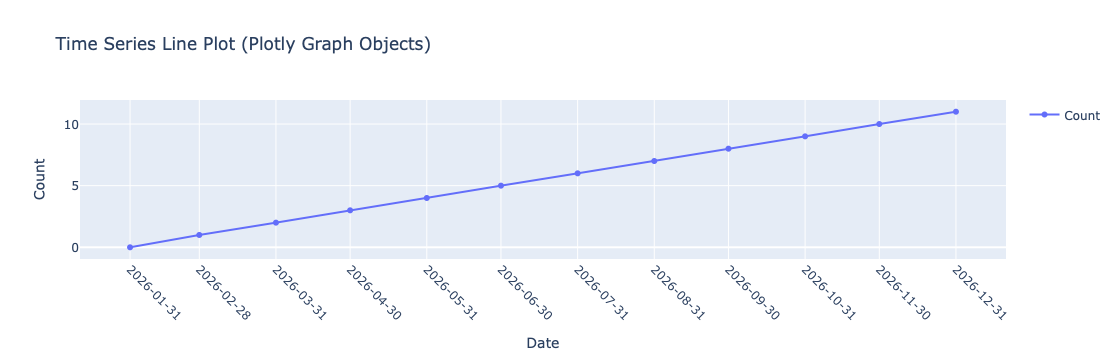

In [72]:
import plotly.graph_objects as go

fig_go_line = go.Figure()

fig_go_line.add_trace(
    go.Scatter(
        x=df.index,
        y=df["count"],
        mode="lines+markers",
        name="Count",
        showlegend=True
    )
)

fig_go_line.update_xaxes(
    tickvals=df.index,
    ticktext=[date.strftime("%Y-%m-%d") for date in df.index], # list comprehension 문법
    tickangle=45
)

fig_go_line.update_layout(
    title="Time Series Line Plot (Plotly Graph Objects)",
    xaxis_title="Date",
    yaxis_title="Count"
)

fig_go_line.show()

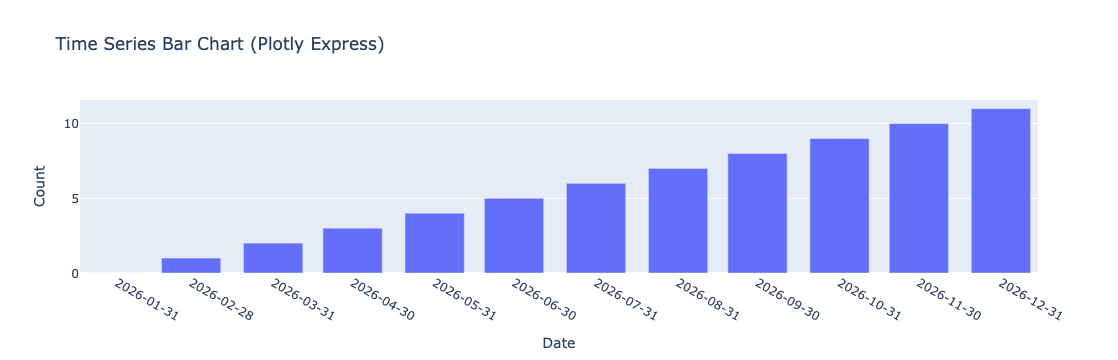

In [78]:
import plotly.express as px

fig_bar = px.bar(
    df,
    x=df.index,
    y=df["count"],
    title="Time Series Bar Chart (Plotly Express)"
)

fig_bar.update_xaxes(
    tickvals=df.index,
    ticktext=[date.strftime("%Y-%m-%d") for date in df.index],
    tickangle=30
)

fig_bar.update_xaxes(title="Date")
fig_bar.update_yaxes(title="Count")

fig_bar.show()